# Phase 5 — Deep Learning
Sept  modules  de  deep  learning,  chacun  rattaché  à  un  besoin  métier.  Tous  doivent  illustrer  explicitement  les
concepts transversaux de la section 2.1 (perte, optimiseur, régularisation, Dropout, Batch Normalization, Early
Stopping, Callbacks) et présenter les courbes d'apprentissage.

Import pour tous le notebook

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import sparse

# Imports TensorFlow / Keras pour les modèles de Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Imports Sklearn pour le prétraitement des données, la division et l'évaluation des modèles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Pour la reproductibilité des résultats, fixe les seeds aléatoires
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Fonction pour trouver le répertoire racine du projet en se basant sur la présence des dossiers 'data' et 'db'
def find_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'db').exists():
            return candidate
    return cwd

# Définit les chemins vers les répertoires importants du projet
ROOT = find_root()
PROCESSED = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
PLOTS = MODELS / 'plots'

# Crée les répertoires s'ils n'existent pas déjà
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)
os.makedirs(PLOTS, exist_ok=True)

print('Project root:', ROOT)
print('Processed dir:', PROCESSED)
print('Models dir:', MODELS)

Project root: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI
Processed dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\data\processed
Models dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\models


## Phase 5 — Deep Learning (hors CNN)

### Structure du notebook
- 5.1 MLP — Prédiction tabulaire
- 5.3 RNN / LSTM — Prévision de la demande
- 5.4 Transformers — Analyse des avis clients
- 5.5 Autoencodeur — Détection d’anomalies / fraude
- 5.6 GAN — Génération de données synthétiques
- 5.7 GNN — Système de recommandation

In [2]:
# Chargement des jeux de données préparés à partir du répertoire PROCESSED
orders_fp = PROCESSED / 'orders_features.csv'
rfm_fp = PROCESSED / 'rfm_matrix.csv'
rfm_std_fp = PROCESSED / 'rfm_standardized.csv'

# Vérifie si les fichiers nécessaires existent avant de les charger
assert orders_fp.exists(), f"Fichier introuvable: {orders_fp}"
assert rfm_fp.exists(), f"Fichier introuvable: {rfm_fp}"

# Charge les fichiers CSV dans des DataFrames pandas
orders = pd.read_csv(orders_fp)
rfm = pd.read_csv(rfm_fp)
# Charge rfm_std si le fichier existe, sinon le définit à None
rfm_std = pd.read_csv(rfm_std_fp) if rfm_std_fp.exists() else None

# Affiche les dimensions (forme) des DataFrames chargés
print('orders shape:', orders.shape)
print('rfm shape:', rfm.shape)
if rfm_std is not None:
    print('rfm_standardized shape:', rfm_std.shape)

orders shape: (99441, 24)
rfm shape: (96096, 4)
rfm_standardized shape: (96096, 3)


## 5.1 MLP — Prédiction tabulaire

Ce module entraîne un perceptron multicouche pour prédire si une commande recevra un avis négatif à partir des variables tabulaires disponibles.

In [3]:
df = pd.read_csv(orders_fp)

# --- Feature Engineering ---
# Création d'une nouvelle caractéristique 'price_per_weight' pour capturer la densité de prix des produits.
df['price_per_weight'] = df['total_price'] / (df['total_weight'] + 0.1) # Ajout de 0.1 pour éviter la division par zéro

# Définition de la colonne cible et des colonnes de caractéristiques à utiliser pour l'entraînement.
TARGET_COL = "bad_review"
FEATURE_COLS = [
    "delivery_days", "delay_days", "purchase_month", "purchase_dow",
    "n_items", "total_price", "total_freight", "total_weight",
    "price_per_weight", "payment_value", "max_installments", "customer_state",
    "main_category", "payment_type", "order_status"
]

# Extraction des caractéristiques (X) et de la cible (y) du DataFrame.
X = df[FEATURE_COLS]
y = df[TARGET_COL].fillna(0).astype(int) # Traite les valeurs manquantes dans la cible et convertit en entier.

# Division des données en ensembles d'entraînement, de validation et de test.
# Utilise `stratify=y` pour maintenir la proportion des classes dans chaque ensemble.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

# Identification des caractéristiques numériques et catégorielles pour le prétraitement.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Création d'un préprocesseur avec ColumnTransformer pour gérer différents types de caractéristiques.
# Les caractéristiques numériques sont imputées avec la médiane puis standardisées.
# Les caractéristiques catégorielles sont imputées avec la valeur la plus fréquente puis encodées en One-Hot.
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

# Application du prétraitement sur les ensembles d'entraînement, de validation et de test.
X_train_proc = preprocessor.fit_transform(X_train).toarray()
X_val_proc = preprocessor.transform(X_val).toarray()
X_test_proc = preprocessor.transform(X_test).toarray()

# Définition de l'architecture du modèle MLP (Multi-Layer Perceptron).
# Le modèle utilise des couches Dense, Batch Normalization et Dropout pour la régularisation.
model = keras.Sequential([
    keras.Input(shape=(X_train_proc.shape[1],)), # Couche d'entrée avec la dimension des caractéristiques prétraitées
    layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)), # Première couche cachée avec régularisation L2
    layers.BatchNormalization(), # Normalisation de Batch pour stabiliser l'entraînement
    layers.Dropout(0.4), # Couche de Dropout pour réduire le surapprentissage
    layers.Dense(64, activation="relu"), # Deuxième couche cachée
    layers.Dense(1, activation="sigmoid"), # Couche de sortie avec activation sigmoïde pour classification binaire
])

# Compilation du modèle avec l'optimiseur Adam, la perte de classification binaire et la métrique AUC.
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])

# Calcul des poids de classe pour gérer le déséquilibre des classes (si une classe est sous-représentée).
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Entraînement du modèle MLP.
# Utilise les poids de classe, un rappel d'arrêt précoce basé sur la perte de validation pour éviter le surapprentissage.
model.fit(X_train_proc, y_train, validation_data=(X_val_proc, y_val), epochs=10, batch_size=64,
          class_weight=class_weights, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=0)

# --- Calibration du seuil de classification ---
# Prédit les probabilités sur l'ensemble de validation pour trouver le meilleur seuil.
y_val_proba = model.predict(X_val_proc, verbose=0).ravel()
thresholds = np.linspace(0.3, 0.7, 20) # Explore différents seuils entre 0.3 et 0.7
scores = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds] # Calcule le F1-score pour chaque seuil
best_threshold = thresholds[np.argmax(scores)] # Sélectionne le seuil qui maximise le F1-score

# Évaluation du modèle final sur l'ensemble de test en utilisant le meilleur seuil trouvé.
y_pred_proba = model.predict(X_test_proc, verbose=0).ravel()
y_pred = (y_pred_proba >= best_threshold).astype(int)

print(f"Meilleur seuil trouvé: {best_threshold:.2f}")
print(classification_report(y_test, y_pred))

Meilleur seuil trouvé: 0.66
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     12737
           1       0.61      0.44      0.52      2180

    accuracy                           0.88     14917
   macro avg       0.76      0.70      0.72     14917
weighted avg       0.87      0.88      0.87     14917



In [4]:
# Définir une fonction qui construit et compile le modèle Keras.
# Les hyperparamètres à optimiser sont passés comme arguments à cette fonction.
def build_mlp_model_for_tuning(input_dim, hidden_layer_1_units=128, dropout_rate=0.4, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(hidden_layer_1_units, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    # Utilise l'optimiseur Adam avec le taux d'apprentissage spécifié
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Compile le modèle avec la perte de classification binaire et la métrique AUC
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    return model

# Encapsuler le modèle Keras dans un KerasClassifier pour l'utiliser avec scikit-learn
# input_dim est crucial et doit correspondre à la dimension des caractéristiques prétraitées.
keras_clf = KerasClassifier(
    model=build_mlp_model_for_tuning,
    input_dim=X_train_proc.shape[1],
    verbose=0, # Supprimer le verbose pour l'entraînement pendant la recherche d'hyperparamètres
)

# Définir les distributions d'hyperparamètres à échantillonner pour la recherche aléatoire
param_dist = {
    'model__hidden_layer_1_units': randint(64, 256), # Nombre d'unités pour la première couche dense (entre 64 et 255)
    'model__dropout_rate': uniform(0.1, 0.6), # Taux de dropout entre 0.1 et 0.7 (0.1 + 0.6)
    'model__learning_rate': uniform(0.0001, 0.005), # Taux d'apprentissage entre 0.0001 et 0.0051
    'batch_size': [32, 64, 128], # Taille du lot pour l'entraînement
    'epochs': [10, 20, 30] # Nombre maximal d'époques pour chaque combinaison d'hyperparamètres
}

# Configurer les callbacks pour l'entraînement du modèle Keras au sein de GridSearchCV/RandomizedSearchCV
early_stopping_callback = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss')

# Préparer les paramètres à passer à la méthode `fit` du KerasClassifier (utilisé par RandomizedSearchCV)
# X_val_proc et y_val sont définis dans la cellule b0c4bd66 pour la validation
fit_params = {
    'class_weight': class_weights, # Poids des classes pour gérer le déséquilibre
    'callbacks': [early_stopping_callback], # Utilisation de l'arrêt précoce
    'validation_data': (X_val_proc, y_val),
    'verbose': 0 # Ne pas afficher le détail de l'entraînement de chaque modèle
}

# Initialiser RandomizedSearchCV pour explorer l'espace des hyperparamètres
# n_iter = 10 signifie que 10 combinaisons aléatoires d'hyperparamètres seront testées
# scoring='roc_auc' utilise l'aire sous la courbe ROC pour évaluer les modèles
# cv=3 indique une validation croisée à 3 plis
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=10, # Nombre d'itérations, peut être augmenté si le temps le permet
    scoring='roc_auc', # Utiliser AUC comme métrique d'évaluation
    cv=3, # 3-fold cross-validation
    random_state=SEED,
    verbose=2,
    error_score='raise'
)

print("Démarrage de la recherche d'hyperparamètres... Ceci peut prendre un certain temps.")
# Lancer la recherche d'hyperparamètres sur l'ensemble d'entraînement
# X_train_proc et y_train sont définis dans la cellule b0c4bd66
random_search.fit(X_train_proc, y_train, **fit_params)

print("\nRecherche d'hyperparamètres terminée.")
print(f"Meilleurs hyperparamètres trouvés: {random_search.best_params_}")
print(f"Meilleur score (AUC) trouvé: {random_search.best_score_:.4f}")

# Évaluer le meilleur modèle trouvé par RandomizedSearchCV sur l'ensemble de test final
best_model = random_search.best_estimator_
# Prédire les probabilités pour la classe positive
y_pred_proba_optimized = best_model.predict_proba(X_test_proc)[:, 1] # Pour la métrique AUC

# Pour une comparaison juste avec le classification_report, nous utiliserons un seuil de 0.5.
# Une calibration de seuil supplémentaire pourrait être effectuée ici si nécessaire pour optimiser d'autres métriques.
y_pred_optimized = (y_pred_proba_optimized >= 0.5).astype(int)

print("\nRapport de classification pour le modèle optimisé sur l'ensemble de test:")
print(classification_report(y_test, y_pred_optimized))

Démarrage de la recherche d'hyperparamètres... Ceci peut prendre un certain temps.
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=128, epochs=10, model__dropout_rate=0.2100608739196983, model__hidden_layer_1_units=135, model__learning_rate=0.003093292420985183; total time=  44.0s
[CV] END batch_size=128, epochs=10, model__dropout_rate=0.2100608739196983, model__hidden_layer_1_units=135, model__learning_rate=0.003093292420985183; total time=  41.5s
[CV] END batch_size=128, epochs=10, model__dropout_rate=0.2100608739196983, model__hidden_layer_1_units=135, model__learning_rate=0.003093292420985183; total time=  24.0s
[CV] END batch_size=128, epochs=20, model__dropout_rate=0.1935967122017216, model__hidden_layer_1_units=138, model__learning_rate=0.0023962444598293357; total time=  30.5s
[CV] END batch_size=128, epochs=20, model__dropout_rate=0.1935967122017216, model__hidden_layer_1_units=138, model__learning_rate=0.0023962444598293357; total time=  30.9s

e:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\.venv\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Recherche d'hyperparamètres terminée.
Meilleurs hyperparamètres trouvés: {'batch_size': 128, 'epochs': 20, 'model__dropout_rate': np.float64(0.6693313223519999), 'model__hidden_layer_1_units': 123, 'model__learning_rate': np.float64(0.0029164410892276965)}
Meilleur score (AUC) trouvé: 0.7855

Rapport de classification pour le modèle optimisé sur l'ensemble de test:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     12737
           1       0.45      0.59      0.51      2180

    accuracy                           0.83     14917
   macro avg       0.69      0.73      0.70     14917
weighted avg       0.86      0.83      0.84     14917



## 5.3 RNN / LSTM — Prévision de la demande

Ce module construit une série temporelle journalière à partir des commandes et entraîne un LSTM pour prévoir la demande du jour suivant.

### 5.3.1 RNN (Réseau de Neurones Récurrents) Simple

Nous allons d'abord implémenter un RNN simple pour la prévision de la demande, en utilisant les mêmes données et la même approche de fenêtrage que pour le LSTM. Cela permet de comparer la performance entre un RNN de base et sa version plus avancée (LSTM).

RNN MAE: 24.8736
RNN RMSE: 33.8997
RNN R2: 0.9128


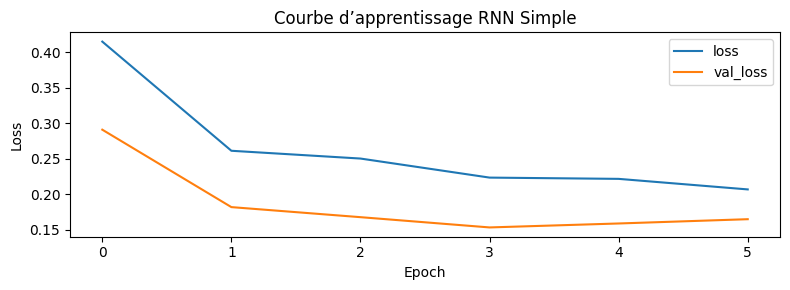

In [5]:
# Définit le nombre de pas de temps à considérer pour chaque prédiction (look_back)
look_back = 14

# Construit un modèle Simple RNN (Réseau de Neurones Récurrents) en utilisant Keras Sequential API
rnn_model = keras.Sequential([
    layers.Input(shape=(look_back, 1)), # Couche d'entrée: look_back pas de temps, 1 caractéristique
    layers.SimpleRNN(64, return_sequences=False), # Couche SimpleRNN avec 64 unités, ne retourne pas toutes les séquences
    layers.Dropout(0.3), # Couche de Dropout pour éviter le surapprentissage
    layers.Dense(32, activation='relu'), # Couche Dense avec activation ReLU
    layers.Dense(1) # Couche de sortie pour la prédiction d'une seule valeur
])

# Compile le modèle RNN avec l'optimiseur Adam et la perte MSE (Mean Squared Error)
rnn_model.compile(optimizer='adam', loss='mse')

# Prépare les données pour la série temporelle
orders_ts = orders.copy()
orders_ts['order_purchase_timestamp'] = pd.to_datetime(orders_ts['order_purchase_timestamp']) # Convertit en datetime
orders_daily = (
    orders_ts.set_index('order_purchase_timestamp')
    .resample('D') # Rééchantillonne les données par jour
    .size() # Compte le nombre de commandes par jour
    .reset_index(name='orders_count')
).sort_values('order_purchase_timestamp').reset_index(drop=True)

# Divise les données chronologiquement en ensembles d'entraînement et de test
train_size = int(len(orders_daily) * 0.8)
train_data_raw = orders_daily['orders_count'].iloc[:train_size].values.reshape(-1, 1)
test_data_raw = orders_daily['orders_count'].iloc[train_size:].values.reshape(-1, 1)

# Mise à l'échelle des données (StandardScaler) pour normaliser les valeurs
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data_raw) # Fit et transforme les données d'entraînement
test_scaled = scaler.transform(test_data_raw) # Transforme les données de test en utilisant le scaler entraîné sur les données d'entraînement

# Fonction utilitaire pour créer des séquences (X) et des cibles (y) pour les modèles RNN/LSTM
def create_sequences(data, look_back):
    X_seq, y_seq = [], []
    for i in range(len(data) - look_back):
        X_seq.append(data[i:(i + look_back), 0]) # Séquence d'entrée
        y_seq.append(data[i + look_back, 0]) # Cible (valeur suivante dans la série)
    return np.array(X_seq), np.array(y_seq)

# Crée les séquences pour les ensembles d'entraînement et de test
X_train_ts, y_train_ts = create_sequences(train_scaled, look_back)
X_test, y_test = create_sequences(test_scaled, look_back)

# Remodèle les données pour l'entrée du RNN (samples, time_steps, features)
X_train_ts = X_train_ts.reshape((-1, look_back, 1))
X_test = X_test.reshape((-1, look_back, 1))

# Entraîne le modèle RNN
rnn_history = rnn_model.fit(
    X_train_ts, y_train_ts,
    validation_split=0.1, # Utilise 10% des données d'entraînement pour la validation
    epochs=8,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)] # Callback pour l'arrêt précoce
)

# Inverse la mise à l'échelle pour obtenir les valeurs réelles de la cible de test
actual_inv = scaler.inverse_transform(np.column_stack([y_test]))[:, 0]

# Fait des prédictions avec le modèle RNN sur l'ensemble de test et inverse la mise à l'échelle
rnn_pred = rnn_model.predict(X_test, verbose=0).ravel()
rnn_pred_inv = scaler.inverse_transform(np.column_stack([rnn_pred]))[:, 0]

# Calcule et affiche les métriques d'évaluation pour le modèle RNN
rnn_mae = mean_absolute_error(actual_inv, rnn_pred_inv)
rnn_rmse = np.sqrt(mean_squared_error(actual_inv, rnn_pred_inv))
rnn_r2 = r2_score(actual_inv, rnn_pred_inv)

print('RNN MAE:', round(rnn_mae, 4))
print('RNN RMSE:', round(rnn_rmse, 4))
print('RNN R2:', round(rnn_r2, 4))

# Trace les courbes d'apprentissage (perte d'entraînement et de validation)
pd.DataFrame(rnn_history.history)[['loss', 'val_loss']].plot(figsize=(8, 3))
plt.title('Courbe d’apprentissage RNN Simple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

# Sauvegarde le modèle RNN entraîné
rnn_model.save(MODELS / 'rnn_demand.keras')

### 5.3.2 LSTM (Long Short-Term Memory)

Voici l'implémentation du modèle LSTM, qui est une forme plus sophistiquée de RNN, utilisant les mêmes données et la même approche de fenêtrage. L'objectif est de voir si le LSTM surpasse le RNN simple, notamment pour capturer les dépendances à long terme dans la série temporelle.

LSTM MAE: 36.4586
LSTM RMSE: 49.9184
LSTM R2: 0.8109


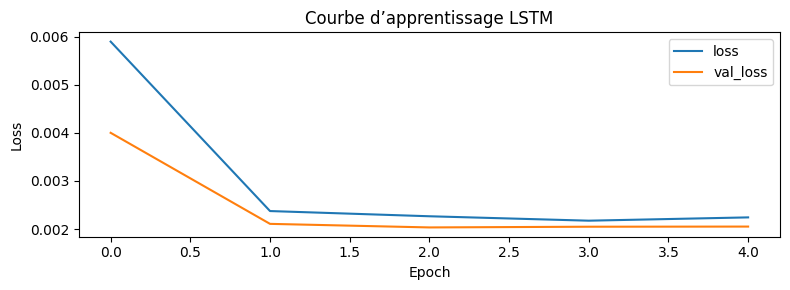

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Importe MinMaxScaler, utilisé ici à la place de StandardScaler

# Charge les données brutes et les traite pour la série temporelle
orders_ts = pd.read_csv(orders_fp)
orders_ts['order_purchase_timestamp'] = pd.to_datetime(orders_ts['order_purchase_timestamp']) # Convertit en datetime
orders_daily = (
    orders_ts.set_index('order_purchase_timestamp')
    .resample('D') # Rééchantillonne les données par jour
    .size() # Compte le nombre de commandes par jour
    .reset_index(name='orders_count')
)
orders_daily = orders_daily.sort_values('order_purchase_timestamp').reset_index(drop=True)
orders_daily.columns = ['order_purchase_timestamp', 'orders_count'] # Renomme les colonnes

look_back = 14 # Définit le nombre de pas de temps à considérer pour chaque prédiction

# Divise les données chronologiquement en ensembles d'entraînement et de test
train_size = int(len(orders_daily) * 0.8)
train_data_raw = orders_daily['orders_count'].iloc[:train_size].values.reshape(-1, 1)
test_data_raw = orders_daily['orders_count'].iloc[train_size:].values.reshape(-1, 1)

# Fit le scaler uniquement sur les données d'entraînement et transforme les deux ensembles
scaler = MinMaxScaler() # Utilise MinMaxScaler pour ramener les valeurs entre 0 et 1
train_scaled = scaler.fit_transform(train_data_raw)
test_scaled = scaler.transform(test_data_raw)

# Fonction utilitaire pour créer des séquences pour les modèles LSTM
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# Crée les séquences pour les ensembles d'entraînement et de test
X_train, y_train = create_sequences(train_scaled, look_back)
X_test, y_test = create_sequences(test_scaled, look_back)

# Remodèle les données pour l'entrée LSTM (samples, time_steps, features)
X_train = X_train.reshape((-1, look_back, 1))
X_test = X_test.reshape((-1, look_back, 1))

# Construit le modèle LSTM (Long Short-Term Memory) en utilisant Keras Sequential API
lstm_model = keras.Sequential([
    layers.Input(shape=(look_back, 1)), # Couche d'entrée
    layers.LSTM(64, return_sequences=False), # Couche LSTM avec 64 unités, ne retourne pas toutes les séquences
    layers.Dropout(0.3), # Couche de Dropout
    layers.Dense(32, activation='relu'), # Couche Dense avec activation ReLU
    layers.Dense(1) # Couche de sortie
])

# Compile le modèle LSTM avec l'optimiseur Adam et la perte MSE
lstm_model.compile(optimizer='adam', loss='mse')

# Entraîne le modèle LSTM
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=32,
    verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

# Fait des prédictions avec le modèle LSTM sur l'ensemble de test et inverse la mise à l'échelle
pred = lstm_model.predict(X_test, verbose=0).ravel()
pred_inv = scaler.inverse_transform(np.column_stack([pred]))[:, 0]
actual_inv = scaler.inverse_transform(np.column_stack([y_test]))[:, 0]

# Calcule et affiche les métriques d'évaluation pour le modèle LSTM
mae = mean_absolute_error(actual_inv, pred_inv)
rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
r2 = r2_score(actual_inv, pred_inv)

print('LSTM MAE:', round(mae, 4))
print('LSTM RMSE:', round(rmse, 4))
print('LSTM R2:', round(r2, 4))

# Trace les courbes d'apprentissage
pd.DataFrame(lstm_history.history)[['loss', 'val_loss']].plot(figsize=(8, 3))
plt.title('Courbe d’apprentissage LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

# Sauvegarde le modèle LSTM entraîné et les données journalières
lstm_model.save(MODELS / 'lstm_demand.keras')
orders_daily.to_csv(MODELS / 'daily_orders.csv', index=False)

### 5.3.3 Évaluation Comparative des Modèles de Prévision

Nous comparons ici visuellement les performances du RNN et du LSTM par rapport aux données réelles sur la période de test.

,Modèle,MAE,RMSE,R2 Score
0,Simple RNN,24.873569,33.899690,0.912796
1,LSTM,36.458615,49.918404,0.810912


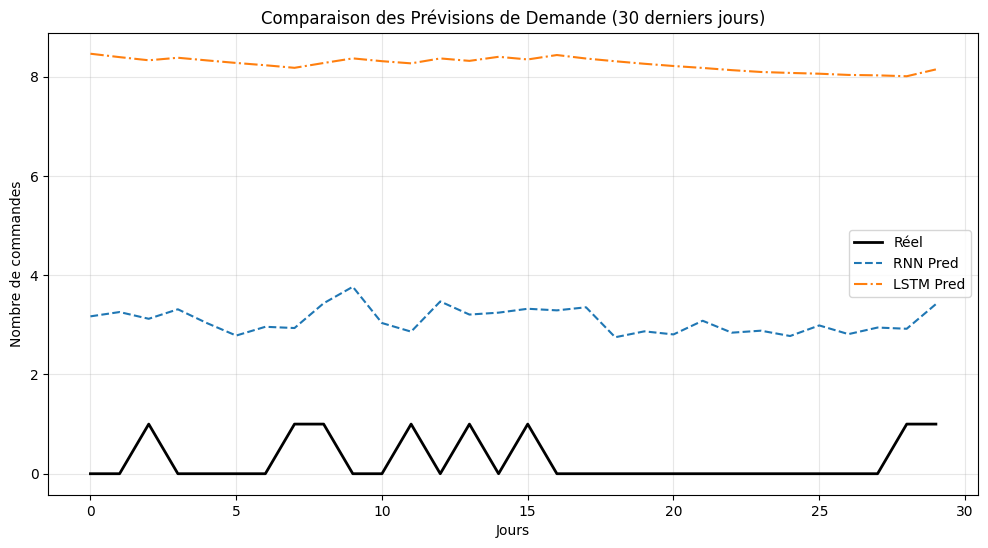

In [7]:
import pandas as pd # Importe la bibliothèque pandas pour la manipulation de données
import matplotlib.pyplot as plt # Importe pyplot de matplotlib pour la création de graphiques

# Crée un tableau comparatif des métriques de performance pour les modèles RNN et LSTM
metrics_data = {
    'Modèle': ['Simple RNN', 'LSTM'],
    'MAE': [rnn_mae, mae],
    'RMSE': [rnn_rmse, rmse],
    'R2 Score': [rnn_r2, r2]
}
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df) # Affiche le DataFrame des métriques

# Visualisation des prédictions des 30 derniers jours pour comparer les modèles au réel
plt.figure(figsize=(12, 6)) # Définit la taille de la figure
plt.plot(actual_inv[-30:], label='Réel', color='black', linewidth=2) # Trace les valeurs réelles
plt.plot(rnn_pred_inv[-30:], label='RNN Pred', linestyle='--') # Trace les prédictions du RNN
plt.plot(pred_inv[-30:], label='LSTM Pred', linestyle='-.') # Trace les prédictions du LSTM
plt.title('Comparaison des Prévisions de Demande (30 derniers jours)') # Ajoute un titre au graphique
plt.xlabel('Jours') # Étiquette de l'axe X
plt.ylabel('Nombre de commandes') # Étiquette de l'axe Y
plt.legend() # Affiche la légende
plt.grid(True, alpha=0.3) # Ajoute une grille
plt.show() # Affiche le graphique

## 5.4 Transformers — Analyse des avis clients

Ce module entraîne un modèle Transformer simple pour l’analyse de sentiment des avis clients.

In [8]:
reviews_path = ROOT / 'data' / 'raw' / 'olist_order_reviews_dataset.csv' # Définit le chemin du fichier des avis clients
reviews = pd.read_csv(reviews_path) # Charge le fichier CSV dans un DataFrame

# Nettoyage et préparation des données des avis
reviews = reviews.dropna(subset=['review_comment_message']).copy() # Supprime les lignes avec des commentaires manquants
reviews['review_comment_message'] = reviews['review_comment_message'].astype(str) # Convertit les commentaires en chaîne de caractères
reviews = reviews[reviews['review_score'].isin([1, 2, 4, 5])].copy() # Filtre les avis pour ne garder que les scores 1, 2, 4, 5
reviews['label'] = (reviews['review_score'] >= 4).astype(int) # Crée une étiquette binaire: 1 pour 'bon avis' (score >= 4), 0 sinon
reviews = reviews.sample(n=min(8000, len(reviews)), random_state=SEED).reset_index(drop=True) # Échantillonne un sous-ensemble des données pour des raisons de performance

texts = reviews['review_comment_message'].tolist() # Convertit les commentaires en liste
labels = reviews['label'].to_numpy() # Convertit les étiquettes en tableau numpy

# Tokenisation des textes
tokenizer = keras.preprocessing.text.Tokenizer(num_words=10000, oov_token='<OOV>') # Initialise le tokenizer avec 10000 mots les plus fréquents et un token OOV
tokenizer.fit_on_texts(texts) # Adapte le tokenizer aux textes
sequences = tokenizer.texts_to_sequences(texts) # Convertit les textes en séquences d'entiers
X = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=80, padding='post', truncating='post') # Pad les séquences pour avoir une longueur fixe de 80

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=SEED, stratify=labels # Stratifie pour maintenir la proportion des classes
)

# Définition de la classe TransformerBlock
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads) # Couche d'attention multi-tête
        self.ffn = keras.Sequential([ # Réseau de feed-forward
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6) # Normalisation de couche
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate) # Couche de dropout
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs) # Applique l'attention multi-tête
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output) # Ajoute la connexion résiduelle et normalise
        ffn_output = self.ffn(out1) # Applique le réseau feed-forward
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output) # Ajoute la connexion résiduelle et normalise

# Construction du modèle Transformer
inputs = layers.Input(shape=(80,)) # Couche d'entrée avec une longueur de séquence de 80
x = layers.Embedding(input_dim=10000, output_dim=64, input_length=80)(inputs) # Couche d'embedding pour convertir les tokens en vecteurs denses
x = layers.SpatialDropout1D(0.2)(x) # Dropout spatial pour les embeddings
x = TransformerBlock(64, 2, 128)(x) # Bloc Transformer
x = layers.GlobalAveragePooling1D()(x) # Pooling global moyen
x = layers.Dense(64, activation='relu')(x) # Couche Dense
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x) # Couche de sortie pour la classification binaire

transformer_model = keras.Model(inputs, outputs) # Crée le modèle Keras
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compile le modèle

# Entraînement du modèle Transformer
transformer_history = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=0,
)

# Évaluation du modèle
y_pred = (transformer_model.predict(X_test, verbose=0).ravel() >= 0.5).astype(int) # Prédictions binaires
print('Transformer accuracy:', round(accuracy_score(y_test, y_pred), 4)) # Affiche l'accuracy
print(classification_report(y_test, y_pred, target_names=['negative', 'positive'])) # Affiche le rapport de classification

# Sauvegarde du modèle Transformer
transformer_model.save(MODELS / 'transformer_reviews.keras')

e:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Transformer accuracy: 0.9081
              precision    recall  f1-score   support

    negative       0.86      0.82      0.84       469
    positive       0.93      0.95      0.94      1131

    accuracy                           0.91      1600
   macro avg       0.89      0.88      0.89      1600
weighted avg       0.91      0.91      0.91      1600



## 5.5 Autoencodeur — Détection d’anomalies / fraude

Ce module entraîne un autoencodeur sur des commandes normales et repère les anomalies par une erreur de reconstruction élevée.

Epoch 1/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.2070 - val_loss: 0.0371
Epoch 2/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - loss: 0.0231 - val_loss: 0.0039
Epoch 3/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step - loss: 0.0020 - val_loss: 5.1537e-04
Epoch 4/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - loss: 4.1555e-04 - val_loss: 1.2117e-04
Epoch 5/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - loss: 4.8053e-04 - val_loss: 6.2261e-05
Epoch 6/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - loss: 2.5875e-04 - val_loss: 3.2494e-05
Epoch 7/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - loss: 2.2058e-04 - val_loss: 1.7599e-05
Epoch 8/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step - loss: 2.5587e-04 - val_loss: 1.4466e-05
Epoch 9/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - loss: 1.4871e-04 - val_loss: 1.2322e-05
Epoch 10/20
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 1s 895us/step - loss: 1.2957e-04 - val_loss: 9.6529e-06
Epoch 11/20
1357/1357 ━━━━━━━━━━━━━━━━━━━

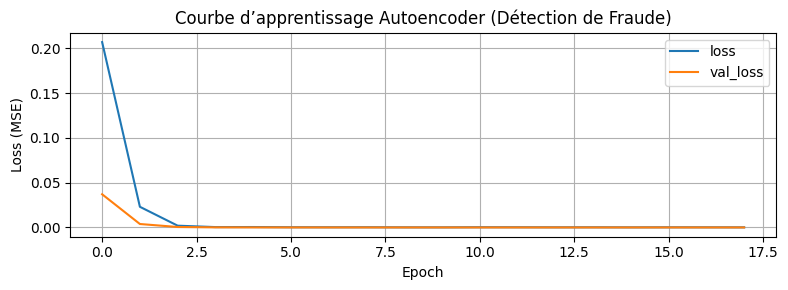

['E:\\Data\\CDI_College\\Cours_Profession_de_Inteligence_Artificiel\\16-Projet_intergration\\RetailSenseAI\\models\\autoencoder_scaler_fraud.joblib']

In [9]:
# 1. Sélection des caractéristiques pertinentes pour la détection d'anomalies
features_auto = [
    'total_price', 'total_freight', 'total_weight', 'n_items',
    'max_installments', 'payment_value', 'delivery_days', 'delay_days'
]

anomaly_df = orders[features_auto].copy() # Crée un DataFrame avec les caractéristiques sélectionnées
anomaly_df = anomaly_df.dropna() # Supprime les lignes avec des valeurs manquantes

# 2. Standardisation des données
scaler_ae = StandardScaler() # Initialise un StandardScaler
X_anom = scaler_ae.fit_transform(anomaly_df) # Adapte et transforme les données

input_dim = X_anom.shape[1] # Dimension d'entrée de l'autoencodeur
bottleneck_dim = 8 # Taille du goulot d'étranglement (couche latente) demandée

# 3. Architecture de l'Autoencodeur
autoencoder = keras.Sequential([
    # Encodeur
    layers.Input(shape=(input_dim,)), # Couche d'entrée
    layers.Dense(16, activation='relu'), # Première couche dense de l'encodeur
    layers.Dense(bottleneck_dim, activation='relu'), # Goulot d'étranglement (couche latente)
    # Décodeur
    layers.Dense(16, activation='relu'), # Première couche dense du décodeur
    layers.Dense(input_dim, activation='linear') # Couche de sortie du décodeur, avec la même dimension que l'entrée
])

# 4. Compilation et Entraînement de l'Autoencodeur
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse') # Compile avec Adam et la perte MSE

# Entraînement sur l'ensemble des données (en supposant que la majorité sont des données 'normales')
auto_history = autoencoder.fit(
    X_anom,
    X_anom, # L'autoencodeur tente de reconstruire son entrée, donc X et y sont les mêmes
    epochs=20,
    batch_size=64, # Taille du lot d'entraînement
    validation_split=0.1, # Utilise 10% des données pour la validation
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)] # Callback pour l'arrêt précoce
)

# 5. Calcul de l'erreur de reconstruction et du drapeau d'anomalie
reconstructions = autoencoder.predict(X_anom, verbose=0) # Prédit les reconstructions pour toutes les données
errors = np.mean(np.square(X_anom - reconstructions), axis=1) # Calcule l'erreur de reconstruction (MSE par échantillon)

# Définit un seuil d'anomalie au 95e percentile des erreurs de reconstruction
threshold = np.quantile(errors, 0.95)
flagged = (errors > threshold).astype(int) # Marque les points dont l'erreur est supérieure au seuil comme anomalies

print(f'\nAutoencoder threshold (95th percentile): {round(threshold, 4)}')
print(f'Anomalies detected: {flagged.sum()} / {len(flagged)}')

# Visualisation des pertes d'entraînement et de validation
pd.DataFrame(auto_history.history)[['loss', 'val_loss']].plot(figsize=(8, 3))
plt.title('Courbe d’apprentissage Autoencoder (Détection de Fraude)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sauvegarde du modèle autoencodeur et du scaler
autoencoder.save(MODELS / 'autoencoder_fraud_detection.keras')
joblib.dump(scaler_ae, MODELS / 'autoencoder_scaler_fraud.joblib')

## 5.6 GAN — Génération de données synthétiques

Ce module entraîne un générateur et un discriminateur simples sur la matrice RFM standardisée pour produire des profils clients synthétiques.

e:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\.venv\lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


GAN training completed.


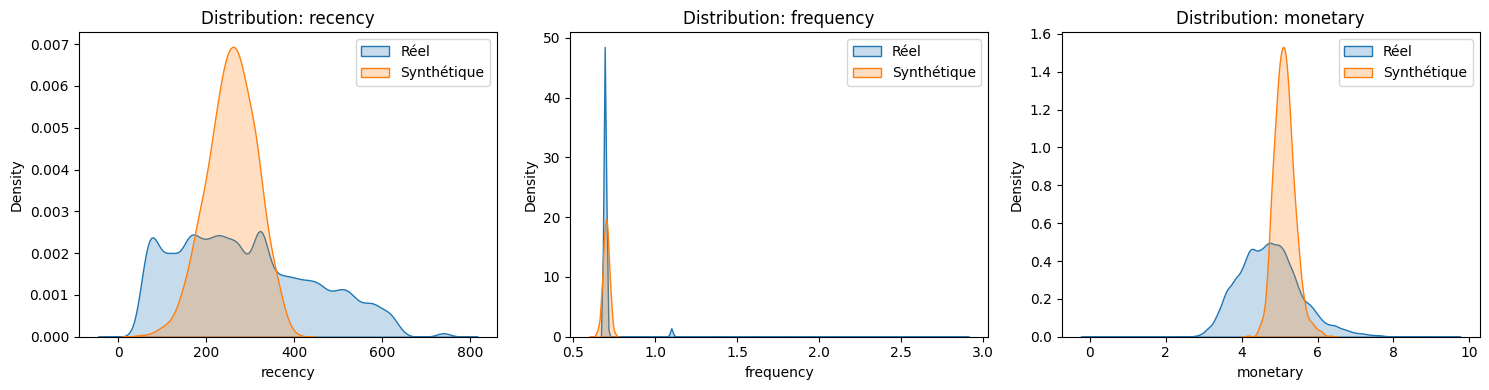

['E:\\Data\\CDI_College\\Cours_Profession_de_Inteligence_Artificiel\\16-Projet_intergration\\RetailSenseAI\\models\\gan_scaler.joblib']

In [10]:
# 1. Préparation des données réelles
rfm_features = rfm_std[['recency', 'frequency', 'monetary']].dropna().copy() # Sélectionne les caractéristiques RFM standardisées
scaler_gan = StandardScaler() # Initialise un StandardScaler pour normaliser les données réelles
real_data = scaler_gan.fit_transform(rfm_features) # Adapte et transforme les données réelles

# Hyperparamètres du GAN
noise_dim = 10 # Dimension du vecteur de bruit en entrée du générateur
data_dim = 3 # Dimension des données réelles (recency, frequency, monetary)
batch_size = 128 # Taille du lot pour l'entraînement
epochs = 50 # Nombre d'époques d'entraînement (augmenté pour une meilleure convergence)
lr = 0.0002 # Taux d'apprentissage pour l'optimiseur Adam
beta1 = 0.5 # Paramètre beta1 pour l'optimiseur Adam

# 2. Architectures du Générateur et du Discriminateur
# Générateur: prend un vecteur de bruit et génère des données synthétiques
def build_generator():
    model = keras.Sequential([
        Input(shape=(noise_dim,)), # Couche d'entrée pour le bruit
        layers.Dense(32),
        layers.LeakyReLU(negative_slope=0.2), # Activation LeakyReLU
        layers.BatchNormalization(), # Normalisation de batch
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(data_dim, activation='linear') # Couche de sortie pour générer des données de la même dimension que les données réelles
    ])
    return model

# Discriminateur: prend des données (réelles ou synthétiques) et prédit si elles sont réelles ou fausses
def build_discriminator():
    model = keras.Sequential([
        Input(shape=(data_dim,)), # Couche d'entrée pour les données
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3), # Dropout pour la régularisation
        layers.Dense(32),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1, activation='sigmoid') # Couche de sortie avec activation Sigmoid pour la classification binaire
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

# 3. Compilation des modèles
# Compile le discriminateur
opt = optimizers.Adam(learning_rate=lr, beta_1=beta1)
discriminator.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Pour l'entraînement du GAN, le discriminateur est figé (non entraînable)
discriminator.trainable = False
gan_input = Input(shape=(noise_dim,)) # Entrée du GAN (bruit)
gan_output = discriminator(generator(gan_input)) # La sortie du générateur est passée au discriminateur
gan = Model(gan_input, gan_output) # Crée le modèle GAN (générateur + discriminateur figé)
gan.compile(loss='binary_crossentropy', optimizer=opt) # Compile le GAN

# 4. Boucle d'entraînement du GAN
for epoch in range(epochs):
    # Entraîner le Discriminateur
    # Sélectionne un lot de vraies données
    idx = np.random.randint(0, real_data.shape[0], batch_size)
    real_samples = real_data[idx]

    # Génère des fausses données à partir du bruit
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_samples = generator.predict(noise, verbose=0)

    # Entraîne le discriminateur sur les vraies données (étiquette 1) et les fausses données (étiquette 0)
    d_loss_real = discriminator.train_on_batch(real_samples, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_samples, np.zeros((batch_size, 1)))

    # Entraîner le Générateur (via le modèle GAN)
    # Le générateur essaie de tromper le discriminateur en générant des données que le discriminateur classerait comme réelles (étiquette 1)
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

print('GAN training completed.')

# 5. Visualisation des résultats
# Génère des données synthétiques après l'entraînement
noise = np.random.normal(0, 1, (1000, noise_dim))
generated_data = generator.predict(noise, verbose=0)
generated_df = pd.DataFrame(scaler_gan.inverse_transform(generated_data), columns=['recency', 'frequency', 'monetary']) # Inverse la normalisation pour obtenir les valeurs originales

# Trace les distributions des caractéristiques réelles et synthétiques
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['recency', 'frequency', 'monetary']):
    sns.kdeplot(rfm_features[col], ax=axes[i], label='Réel', fill=True) # Distribution des données réelles
    sns.kdeplot(generated_df[col], ax=axes[i], label='Synthétique', fill=True) # Distribution des données synthétiques
    axes[i].set_title(f'Distribution: {col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Sauvegarde le générateur et le scaler
generator.save(MODELS / 'gan_generator.keras')
joblib.dump(scaler_gan, MODELS / 'gan_scaler.joblib')

### 5.6.1 Validation du GAN par Corrélation

Un bon GAN doit non seulement reproduire les distributions (KDE), mais aussi les corrélations entre les variables.

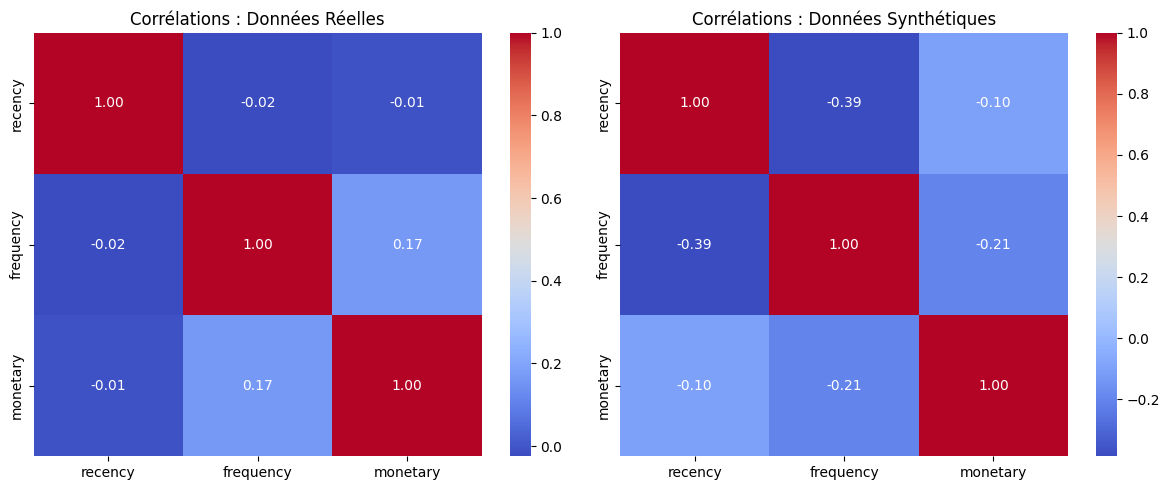

In [11]:
import matplotlib.pyplot as plt # Importe pyplot de matplotlib pour la création de graphiques
import seaborn as sns # Importe seaborn pour la visualisation des données

# Crée une figure avec deux sous-graphiques pour afficher les matrices de corrélation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Trace la matrice de corrélation pour les données réelles
sns.heatmap(rfm_features.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax1) # annot=True affiche les valeurs, cmap='coolwarm' définit la palette de couleurs
ax1.set_title('Corrélations : Données Réelles') # Définit le titre du premier sous-graphique

# Trace la matrice de corrélation pour les données synthétiques générées par le GAN
sns.heatmap(generated_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax2)
ax2.set_title('Corrélations : Données Synthétiques') # Définit le titre du second sous-graphique

plt.tight_layout() # Ajuste automatiquement les paramètres du sous-graphique pour un meilleur agencement
plt.show() # Affiche le graphique

## 5.7 GNN — Système de recommandation

Ce module démontre un concept simple de système de recommandation basé sur les interactions client-produit à l'aide d'un graphe.

In [12]:
# 1. Préparation des données pour la construction du graphe
df_gnn = orders[['customer_id', 'main_category']].dropna().copy() # Sélectionne les IDs clients et les catégories principales, puis supprime les NaN

customers = df_gnn['customer_id'].unique() # Liste unique des IDs clients
products = df_gnn['main_category'].unique() # Liste unique des catégories de produits

# Crée des mappings d'IDs numériques pour les clients et les produits
cust_map = {id: i for i, id in enumerate(customers)}
prod_map = {id: i + len(customers) for i, id in enumerate(products)} # Les IDs produits commencent après les IDs clients
n_nodes = len(customers) + len(products) # Nombre total de nœuds dans le graphe (clients + produits)

# Prépare les arêtes du graphe (connexions client-produit)
edges_from = df_gnn['customer_id'].map(cust_map).values # Nœuds de départ (clients)
edges_to = df_gnn['main_category'].map(prod_map).values # Nœuds d'arrivée (produits)

# Construction de la matrice d'adjacence normalisée (A_hat = D^-0.5 * A * D^-0.5)
# Crée une matrice d'adjacence creuse (sparse) où 1 indique une interaction
adj = sparse.coo_matrix((np.ones(len(edges_from)), (edges_from, edges_to)), shape=(n_nodes, n_nodes))
adj = (adj + adj.T + sparse.eye(n_nodes)).tocoo() # Rend la matrice symétrique et ajoute des boucles sur chaque nœud

# Calcule D^-0.5, où D est la matrice de degrés
d_inv_sqrt = np.power(np.array(adj.sum(1)), -0.5).flatten()
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0. # Gère les divisions par zéro
d_mat = sparse.diags(d_inv_sqrt) # Crée une matrice diagonale de D^-0.5
adj_norm_sp = d_mat.dot(adj).dot(d_mat).tocoo() # Calcule la matrice d'adjacence normalisée

# Conversion en SparseTensor TensorFlow
indices = np.vstack((adj_norm_sp.row, adj_norm_sp.col)).T
adj_tensor = tf.SparseTensor(indices, adj_norm_sp.data.astype('float32'), adj_norm_sp.shape) # Crée un SparseTensor
adj_tensor = tf.sparse.reorder(adj_tensor) # Réorganise les indices pour l'efficacité de TF

# 2. Implémentation d'une couche GCN Native (Graph Convolutional Network)
class NativeGCNLayer(tf.keras.layers.Layer):
    def __init__(self, units, activation='relu'):
        super().__init__()
        self.units = units # Nombre d'unités de sortie
        self.activation = tf.keras.activations.get(activation) # Fonction d'activation

    def build(self, input_shape):
        # Initialise les poids (W) et les biais (b) de la couche
        self.w = self.add_weight(shape=(input_shape[0][-1], self.units), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, inputs):
        x, a = inputs # x sont les caractéristiques des nœuds, a est la matrice d'adjacence
        # Propagation GCN: A_hat * X * W
        x_w = tf.matmul(x, self.w) # Multiplie les caractéristiques par les poids
        out = tf.sparse.sparse_dense_matmul(a, x_w) # Multiplie par la matrice d'adjacence normalisée
        return self.activation(out + self.b) # Applique l'activation et ajoute les biais

# 3. Modèle de Recommandation basé sur GNN
class GNNRecommender(tf.keras.Model):
    def __init__(self, n_hidden):
        super().__init__()
        self.gcn1 = NativeGCNLayer(n_hidden) # Première couche GCN
        self.gcn2 = NativeGCNLayer(n_hidden) # Deuxième couche GCN

    def call(self, inputs):
        x, a = inputs
        x = self.gcn1([x, a]) # Passe par la première couche GCN
        x = self.gcn2([x, a]) # Passe par la deuxième couche GCN
        return x # Retourne les embeddings finaux des nœuds

# Initialisation du modèle GNN
X_gnn = tf.eye(n_nodes, 32) # Crée des embeddings d'identité initiaux pour chaque nœud
model_gnn = GNNRecommender(32) # Initialise le modèle de recommandation avec 32 dimensions cachées
optimizer = tf.keras.optimizers.Adam(0.01) # Optimiseur Adam

# 4. Entraînement du modèle GNN
# Sélectionne un sous-ensemble d'arêtes positives pour l'entraînement
pos_from = tf.constant(edges_from[:1000], dtype=tf.int32)
pos_to = tf.constant(edges_to[:1000], dtype=tf.int32)

print("Démarrage de l'entraînement GNN (Native)... updates...")
for epoch in range(11):
    with tf.GradientTape() as tape: # Enregistre les opérations pour le calcul du gradient
        emb = model_gnn([X_gnn, adj_tensor]) # Calcule les embeddings des nœuds
        v1, v2 = tf.gather(emb, pos_from), tf.gather(emb, pos_to) # Récupère les embeddings des nœuds connectés
        scores = tf.reduce_sum(v1 * v2, axis=1) # Calcule les scores de similarité (produit scalaire)
        # Fonction de perte basée sur la probabilité d'une connexion positive
        loss = -tf.reduce_mean(tf.math.log(tf.sigmoid(scores) + 1e-15))

    grads = tape.gradient(loss, model_gnn.trainable_variables) # Calcule les gradients
    optimizer.apply_gradients(zip(grads, model_gnn.trainable_variables)) # Applique les gradients pour mettre à jour les poids
    if epoch % 5 == 0: print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}") # Affiche la perte périodiquement

# 5. Résultats et Recommandations
final_embeddings = model_gnn([X_gnn, adj_tensor]).numpy() # Obtient les embeddings finaux après entraînement

# Fonction pour obtenir des recommandations pour un client donné
def get_recommendations(customer_id, top_n=5):
    if customer_id not in cust_map: return "Client inconnu" # Gère les clients inconnus
    c_idx = cust_map[customer_id] # Index numérique du client
    # Calcule les scores de similarité entre l'embedding du client et tous les embeddings de produits
    scores = np.dot(final_embeddings[list(prod_map.values())], final_embeddings[c_idx])
    top_indices = np.argsort(scores)[-top_n:][::-1] # Trie et sélectionne les N meilleurs indices
    return [products[i] for i in top_indices] # Retourne les noms des produits recommandés

sample_cust = customers[0] # Sélectionne un client échantillon
print(f"\nRecommandations pour {sample_cust}: {get_recommendations(sample_cust)}") # Affiche les recommandations
# Correction du nom de fichier pour Keras 3: Sauvegarde les poids du modèle GNN
model_gnn.save_weights(str(MODELS / 'gnn_native_recommender.weights.h5'))

Démarrage de l'entraînement GNN (Native)... updates...
Epoch 0, Loss: 0.6931
Epoch 5, Loss: 0.0269
Epoch 10, Loss: 0.0003

Recommandations pour 3ce436f183e68e07877b285a838db11a: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor']
